# Level 2 Backtest System

## 4 Upgrades จาก Level 1

| # | Upgrade | Level 1 | Level 2 |
|---|---|---|---|
| 1 | Signal | Binary predict() | **Probability Edge** = proba − 0.5 |
| 2 | Filter | ไม่มี | **Market Regime Filter** (trend + vol) |
| 3 | Position size | Fixed 10% | **Kelly Criterion** ∝ edge × confidence |
| 4 | Threshold | Fixed 0.52 | **Sharpe-optimized** per walk-forward period |

**เป้าหมาย:** Sharpe > 0.5 consistently, Max DD < 15%

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)

In [16]:
df = pd.read_csv('../../data/processed/features/features_all.csv', parse_dates=['Date'])
df = df.sort_values(['symbol', 'Date']).reset_index(drop=True)

FEATURES = [c for c in df.columns if c not in
            ['Date', 'symbol', 'target', 'Open', 'High', 'Low', 'Close', 'Volume']]

# Top features (from Level 1 importance analysis)
train_base = df[df['Date'] < '2022-01-01']
model_feat = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_feat.fit(train_base[FEATURES], train_base['target'])
imp = pd.Series(model_feat.feature_importances_, index=FEATURES).sort_values(ascending=False)
TOP = imp.head(15).index.tolist()

print(f'Rows: {len(df):,} | Symbols: {df["symbol"].nunique()} | Date: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Top features: {TOP[:5]} ...')

Rows: 16,212 | Symbols: 7 | Date: 2015-10-19 → 2024-12-31
Top features: ['vol_ma', 'trend_strength', 'bb_width', 'vol_20', 'macd_signal'] ...


---
## Section 1 — Probability Edge Signal

```
edge = proba - 0.5
```
- `edge = 0.0` → model ไม่มั่นใจ (proba = 50%)
- `edge = 0.1` → มั่นใจปานกลาง (proba = 60%)
- `edge = 0.2` → มั่นใจมาก (proba = 70%)

ใช้ edge แทน binary label: **ยิ่ง edge สูง → position ใหญ่ขึ้น**

In [17]:
test_base = df[df['Date'] >= '2022-01-01'].reset_index(drop=True)
model_demo = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=30,
                                    max_features='sqrt', random_state=42, n_jobs=-1)
model_demo.fit(train_base[TOP], train_base['target'])
proba_demo = model_demo.predict_proba(test_base[TOP])[:, 1]
edge_demo  = proba_demo - 0.5

print('=== EDGE DISTRIBUTION ===')
print(f'  Edge range : {edge_demo.min():.3f} → {edge_demo.max():.3f}')
print(f'  Mean edge  : {edge_demo.mean():.3f}')
print(f'  Std  edge  : {edge_demo.std():.3f}')
print()

# Edge buckets → precision
print('  Edge bucket → Win Rate (precision):')
edges  = pd.Series(edge_demo, name='edge')
target = test_base['target'].values
for lo, hi in [(-0.5,-0.05), (-0.05,0.0), (0.0,0.02), (0.02,0.05),
               (0.05,0.10), (0.10,0.15), (0.15,0.5)]:
    mask = (edges >= lo) & (edges < hi)
    n    = mask.sum()
    if n == 0: continue
    prec = target[mask].mean()
    label = 'BUY zone' if lo >= 0.02 else ('neutral' if lo >= -0.05 else 'SELL zone')
    print(f'  [{lo:+.2f},{hi:+.2f}): n={n:5,}  win_rate={prec:.3f}  {label}')

=== EDGE DISTRIBUTION ===
  Edge range : -0.179 → 0.175
  Mean edge  : -0.018
  Std  edge  : 0.073

  Edge bucket → Win Rate (precision):
  [-0.50,-0.05): n=1,995  win_rate=0.417  SELL zone
  [-0.05,+0.00): n=1,300  win_rate=0.446  neutral
  [+0.00,+0.02): n=  400  win_rate=0.477  neutral
  [+0.02,+0.05): n=  458  win_rate=0.448  BUY zone
  [+0.05,+0.10): n=  737  win_rate=0.510  BUY zone
  [+0.10,+0.15): n=  345  win_rate=0.490  BUY zone
  [+0.15,+0.50): n=   36  win_rate=0.528  BUY zone


---
## Section 2 — Market Regime Filter

```python
# Trend regime: ราคาอยู่เหนือ SMA50 ไหม? (lag-1)
trend_ok[t] = Close[t-1] > SMA50[t-1]

# Vol regime: volatility สูงผิดปกติไหม? (lag-1)
high_vol[t] = vol20[t-1] > vol20_ma50[t-1]
```

**กลยุทธ์:**
- `trend_ok = False` → ข้ามสัญญาณนั้น (don't trade against trend)
- `high_vol = True` → ลด position เหลือ 50% (ลด risk ใน choppy market)

In [18]:
def add_regime(df, trend_window=50, vol_window=20, vol_ma_window=50):
    """Compute lag-1 regime signals per symbol."""
    df = df.copy()
    trend_list, vol_list = [], []

    for sym, grp in df.groupby('symbol'):
        grp  = grp.sort_values('Date').reset_index(drop=True)
        close = grp['Close']

        sma50     = close.rolling(trend_window).mean()
        trend_raw = (close > sma50).astype(int)

        vol20     = close.pct_change().rolling(vol_window).std()
        vol_ma50  = vol20.rolling(vol_ma_window).mean()
        high_vol  = (vol20 > vol_ma50).astype(int)

        # lag-1 so no look-ahead
        trend_list.append(trend_raw.shift(1).reindex(grp.index))
        vol_list.append(high_vol.shift(1).reindex(grp.index))

    df['trend_ok'] = pd.concat(trend_list).values
    df['high_vol'] = pd.concat(vol_list).values
    return df


df_r = add_regime(df)

# Stats on regime
test_r = df_r[df_r['Date'] >= '2022-01-01']
print('=== REGIME STATS (test period 2022+) ===')
print(f'  trend_ok=1 (uptrend)  : {test_r["trend_ok"].mean():.1%} of rows')
print(f'  high_vol=1 (high vol) : {test_r["high_vol"].mean():.1%} of rows')
print()

# Win rate by regime
print('  Win rate by regime:')
for trend in [0, 1]:
    for hvol in [0, 1]:
        mask = (test_r['trend_ok'] == trend) & (test_r['high_vol'] == hvol)
        n    = mask.sum()
        if n < 50: continue
        wr   = test_r.loc[mask, 'target'].mean()
        label = f'trend={trend} highvol={hvol}'
        print(f'  {label}  n={n:5,}  target_rate={wr:.3f}')

print()
print('  → Trade only when trend_ok=1 (uptrend)')
print('  → Reduce size 50% when high_vol=1')

=== REGIME STATS (test period 2022+) ===
  trend_ok=1 (uptrend)  : 58.7% of rows
  high_vol=1 (high vol) : 44.7% of rows

  Win rate by regime:
  trend=0 highvol=0  n=  993  target_rate=0.456
  trend=0 highvol=1  n=1,184  target_rate=0.440
  trend=1 highvol=0  n=1,924  target_rate=0.448
  trend=1 highvol=1  n=1,170  target_rate=0.459

  → Trade only when trend_ok=1 (uptrend)
  → Reduce size 50% when high_vol=1


---
## Section 3 — Level2Simulator

**Kelly Criterion:**
```
b   = avg_win / |avg_loss|   (win/loss ratio)
f*  = (p*b - (1-p)) / b      (full Kelly fraction)
pos = f* × kelly_fraction × (edge / max_edge)   (quarter-Kelly, scaled by conviction)
pos = min(pos, max_position_pct)                (cap)
pos = pos × 0.5  if high_vol                    (vol reduction)
```

In [19]:
class Level2Simulator:
    """
    Level 2 Portfolio Simulator:
    - Continuous edge signal (proba - 0.5)
    - Regime filter (trend + vol)
    - Kelly position sizing
    - Sharpe-optimized threshold per period
    """

    def __init__(
        self,
        initial_capital : float = 100_000,
        max_positions   : int   = 5,
        kelly_fraction  : float = 0.25,      # quarter-Kelly (conservative)
        max_position_pct: float = 0.15,      # cap per position
        hold_days       : int   = 5,
        tx_cost         : float = 0.0005,
        stop_loss       : float = -0.07,
        min_edge        : float = 0.02,      # proba > 0.52
        use_regime      : bool  = True,
        vol_reduction   : float = 0.5,       # multiply position by this in high vol
    ):
        self.initial_capital  = initial_capital
        self.max_positions    = max_positions
        self.kelly_fraction   = kelly_fraction
        self.max_position_pct = max_position_pct
        self.hold_days        = hold_days
        self.tx_cost          = tx_cost
        self.stop_loss        = stop_loss
        self.min_edge         = min_edge
        self.use_regime       = use_regime
        self.vol_reduction    = vol_reduction

    @staticmethod
    def estimate_kelly_stats(train_df, features, model):
        """Estimate win_rate, avg_win, avg_loss from last 20% of training data."""
        n      = len(train_df)
        val    = train_df.iloc[int(n * 0.8):].reset_index(drop=True)
        probas = model.predict_proba(val[features])[:, 1]
        edge   = probas - 0.5                    # numpy array
        sigs   = edge > 0.02                     # numpy bool array

        trades = []
        for sym, grp in val.groupby('symbol'):
            grp   = grp.sort_values('Date').reset_index(drop=True)
            idx   = grp.index.to_numpy()         # integer positions in val
            c     = grp['Close'].values
            s     = sigs[idx]                    # numpy array — use [i], not .iloc[i]
            for i in range(len(grp) - 5):
                if s[i]:
                    trades.append(c[i + 5] / c[i] - 1 - 0.001)

        if len(trades) < 10:
            return 0.52, 0.025, -0.020          # safe defaults

        t  = np.array(trades)
        wr = (t > 0).mean()
        aw = t[t > 0].mean() if (t > 0).any() else 0.025
        al = t[t < 0].mean() if (t < 0).any() else -0.020
        return float(wr), float(aw), float(al)

    def kelly_pos(self, edge, win_rate, avg_win, avg_loss):
        """Kelly-scaled position size."""
        if avg_loss >= 0: return 0.0
        b      = avg_win / abs(avg_loss)
        p      = win_rate
        full_k = max(0.0, (p * b - (1 - p)) / b)
        edge_scale = min(edge / 0.10, 1.5)
        pos = full_k * self.kelly_fraction * edge_scale
        return min(pos, self.max_position_pct)

    def simulate(self, df, probas, win_rate=0.54, avg_win=0.025, avg_loss=-0.020):
        df = df.copy().reset_index(drop=True)

        if 'trend_ok' not in df.columns:
            df = add_regime(df)

        df['proba']  = np.asarray(probas)
        df['edge']   = df['proba'] - 0.5

        df['raw_signal'] = (df['edge'] >= self.min_edge).astype(int)
        if self.use_regime:
            df['signal'] = df['raw_signal'] * df['trend_ok'].fillna(0).astype(int)
        else:
            df['signal'] = df['raw_signal']

        price_map = df.set_index(['Date', 'symbol'])['Close'].to_dict()
        all_dates = sorted(df['Date'].unique())
        date_to_i = {d: i for i, d in enumerate(all_dates)}

        capital   = float(self.initial_capital)
        positions = []
        daily_rows, trade_rows = [], []

        for today in all_dates:
            today_i    = date_to_i[today]
            today_data = df[df['Date'] == today]

            # ── Close positions ───────────────────────────────────────────
            surviving = []
            for pos in positions:
                dh = today_i - pos['entry_i']
                ep = price_map.get((today, pos['symbol']), pos['entry_price'])
                gr = ep / pos['entry_price'] - 1
                if dh >= self.hold_days or gr <= self.stop_loss:
                    net = gr - self.tx_cost
                    capital += pos['value'] * (1 + net)
                    trade_rows.append({
                        'symbol'      : pos['symbol'],
                        'entry_date'  : pos['entry_date'],
                        'exit_date'   : today,
                        'days_held'   : dh,
                        'gross_ret'   : gr,
                        'net_return'  : net,
                        'edge'        : pos['edge'],
                        'position_pct': pos['value'] / self.initial_capital,
                        'exit_reason' : 'stop' if gr <= self.stop_loss else 'time',
                    })
                else:
                    surviving.append(pos)
            positions = surviving

            # ── Open new positions ────────────────────────────────────────
            capacity  = self.max_positions - len(positions)
            open_syms = {p['symbol'] for p in positions}

            if capacity > 0:
                candidates = (
                    today_data[today_data['signal'] == 1]
                    .sort_values('edge', ascending=False)
                )
                for _, row in candidates.iterrows():
                    if capacity <= 0: break
                    if row['symbol'] in open_syms: continue

                    pos_pct = self.kelly_pos(row['edge'], win_rate, avg_win, avg_loss)

                    if self.use_regime and row.get('high_vol', 0) == 1:
                        pos_pct *= self.vol_reduction

                    tv = capital * pos_pct
                    if tv < 100: continue

                    capital -= tv * (1 + self.tx_cost)
                    positions.append({
                        'symbol'      : row['symbol'],
                        'entry_date'  : today,
                        'entry_i'     : today_i,
                        'entry_price' : row['Close'],
                        'value'       : tv,
                        'edge'        : row['edge'],
                    })
                    open_syms.add(row['symbol'])
                    capacity -= 1

            # ── MTM ──────────────────────────────────────────────────────
            mtm = sum(
                p['value'] * price_map.get((today, p['symbol']), p['entry_price'])
                / p['entry_price'] for p in positions
            )
            daily_rows.append({'date': today, 'portfolio_value': capital + mtm,
                               'n_positions': len(positions)})

        daily_df  = pd.DataFrame(daily_rows).set_index('date')
        trades_df = pd.DataFrame(trade_rows)
        return daily_df, trades_df

    @staticmethod
    def compute_metrics(daily_df, trades_df, rf=0.04):
        pv   = daily_df['portfolio_value']
        ret  = pv.pct_change().fillna(0)
        peak = pv.cummax(); dd = (pv - peak) / peak
        exc  = ret - rf / 252
        sh   = exc.mean() / exc.std() * np.sqrt(252) if exc.std() > 0 else 0
        tr   = pv.iloc[-1] / pv.iloc[0] - 1
        ny   = (pv.index[-1] - pv.index[0]).days / 365.25
        cagr = (1 + tr) ** (1 / ny) - 1 if ny > 0 else 0
        r    = trades_df['net_return'] if len(trades_df) else pd.Series(dtype=float)
        w    = r[r > 0]; l = r[r < 0]
        pf   = w.sum() / abs(l.sum()) if len(l) > 0 and l.sum() != 0 else np.inf
        return {
            'n_trades': len(trades_df), 'win_rate': (r > 0).mean(),
            'profit_factor': pf, 'sharpe': sh, 'max_drawdown': dd.min(),
            'cagr': cagr, 'stop_pct': (trades_df['exit_reason'] == 'stop').mean() if len(trades_df) else 0,
            '_equity': pv, '_drawdown': dd, '_daily': ret,
        }

    @staticmethod
    def print_metrics(m, title='Level 2 Results'):
        pf = f"{m['profit_factor']:.3f}" if m['profit_factor'] != np.inf else '∞'
        print(f"\n{'=' * 55}")
        print(f"  {title}")
        print(f"{'=' * 55}")
        print(f"  Trades        : {m['n_trades']:>8,}")
        print(f"  Win Rate      : {m['win_rate']:>8.1%}")
        print(f"  Profit Factor : {pf:>8}  (good > 1.3)")
        print(f"  Sharpe Ratio  : {m['sharpe']:>8.3f}  (good > 1.0)")
        print(f"  Max Drawdown  : {m['max_drawdown']:>8.1%}  (good < -15%)")
        print(f"  CAGR          : {m['cagr']:>8.1%}")
        print(f"  Stop hits     : {m['stop_pct']:>8.1%}")
        print(f"{'=' * 55}\n")


print('Level2Simulator ready')

Level2Simulator ready


---
## Section 4 — Threshold Optimization (Sharpe-based)

ใช้ **in-sample validation** (last 20% of training data) เพื่อหา min_edge ที่ให้ Sharpe สูงสุด  
ทำแยกใน **ทุก walk-forward period** (ไม่ใช่ global optimization → ไม่ overfitting)

In [20]:
def optimize_edge_threshold(train_df, features, model, edge_range=None):
    """
    Find edge threshold that maximizes Sharpe on training validation split.
    Uses last 20% of training data as held-out validation.
    """
    if edge_range is None:
        edge_range = np.arange(0.00, 0.15, 0.01)

    n   = len(train_df)
    val = train_df.iloc[int(n * 0.8):].reset_index(drop=True)
    if len(val) < 100:
        return 0.02   # fallback default

    val = add_regime(val)
    pb  = model.predict_proba(val[features])[:, 1]
    val['edge']     = pb - 0.5
    val['trend_ok'] = val['trend_ok'].fillna(0)

    best_sh, best_t = -np.inf, 0.02

    for t in edge_range:
        trades = []
        for sym, grp in val.groupby('symbol'):
            grp = grp.sort_values('Date').reset_index(drop=True)
            c   = grp['Close'].values
            sig = ((grp['edge'] >= t) & (grp['trend_ok'] == 1)).values
            for i in range(len(grp) - 5):
                if sig[i]:
                    trades.append({'exit_date': grp['Date'].iloc[i+5],
                                   'ret': c[i+5]/c[i]-1-0.001})

        if len(trades) < 10:
            continue

        t_df   = pd.DataFrame(trades)
        daily  = t_df.groupby('exit_date')['ret'].mean()
        excess = daily - 0.04 / 252
        sh     = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else 0

        if sh > best_sh:
            best_sh = sh
            best_t  = t

    return best_t


# Demo: show threshold optimization on baseline train
model_demo2 = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=30,
                                     max_features='sqrt', random_state=42, n_jobs=-1)
model_demo2.fit(train_base[TOP], train_base['target'])

best_edge = optimize_edge_threshold(train_base, TOP, model_demo2)
print(f'Optimal edge threshold (train < 2022): {best_edge:.2f}  (proba > {0.5+best_edge:.2f})')

Optimal edge threshold (train < 2022): 0.14  (proba > 0.64)


---
## Section 5 — Walk-Forward with Level 2 System

ทุก period:
1. Train model (regularized RF)
2. Optimize edge threshold บน training validation
3. Estimate Kelly stats (win_rate, avg_win, avg_loss) จาก training validation
4. Simulate ด้วย Level2Simulator + regime filter

In [21]:
INITIAL_YEARS = 3
STEP_MONTHS   = 6

min_date = df_r['Date'].min()
max_date = df_r['Date'].max()
cutoff   = min_date + pd.DateOffset(years=INITIAL_YEARS)

wf_periods   = []
all_daily    = []
all_trades   = []
prev_capital = 100_000

while True:
    t_start = cutoff
    t_end   = cutoff + pd.DateOffset(months=STEP_MONTHS)
    if t_end > max_date:
        break

    train_wf = df_r[df_r['Date'] <  t_start]
    test_wf  = df_r[(df_r['Date'] >= t_start) & (df_r['Date'] < t_end)].reset_index(drop=True)

    if len(train_wf) < 500 or len(test_wf) < 50:
        cutoff = t_end
        continue

    # 1. Train
    model_wf = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=30,
        max_features='sqrt', random_state=42, n_jobs=-1,
    )
    model_wf.fit(train_wf[TOP], train_wf['target'])

    # 2. Optimize threshold
    opt_edge = optimize_edge_threshold(train_wf, TOP, model_wf)

    # 3. Kelly stats from training validation
    wr, aw, al = Level2Simulator.estimate_kelly_stats(train_wf, TOP, model_wf)

    # 4. Simulate
    probas_wf = model_wf.predict_proba(test_wf[TOP])[:, 1]
    sim = Level2Simulator(
        initial_capital  = prev_capital,
        max_positions    = 5,
        kelly_fraction   = 0.25,
        max_position_pct = 0.15,
        hold_days        = 5,
        tx_cost          = 0.0005,
        stop_loss        = -0.07,
        min_edge         = opt_edge,
        use_regime       = True,
        vol_reduction    = 0.5,
    )
    daily_wf, trades_wf = sim.simulate(test_wf, probas_wf, wr, aw, al)

    if daily_wf.empty or trades_wf.empty:
        cutoff = t_end
        continue

    prev_capital = daily_wf['portfolio_value'].iloc[-1]
    mx = Level2Simulator.compute_metrics(daily_wf, trades_wf)

    wf_periods.append({
        'period'        : t_start.strftime('%Y-%m'),
        'opt_edge'      : opt_edge,
        'kelly_wr'      : wr,
        'n_trades'      : mx['n_trades'],
        'win_rate'      : mx['win_rate'],
        'profit_factor' : mx['profit_factor'],
        'sharpe'        : mx['sharpe'],
        'max_drawdown'  : mx['max_drawdown'],
        'cagr'          : mx['cagr'],       # ← was 'total_return' (wrong key)
        'stop_pct'      : mx['stop_pct'],
    })
    all_daily.append(daily_wf)
    all_trades.append(trades_wf)

    print(f'  [{t_start.strftime("%Y-%m")}→{t_end.strftime("%Y-%m")}]  '
          f'edge≥{opt_edge:.2f}  trades={mx["n_trades"]:3d}  '
          f'sharpe={mx["sharpe"]:+.2f}  dd={mx["max_drawdown"]:.1%}  '
          f'pf={mx["profit_factor"]:.2f}')

    cutoff = t_end

wf_df      = pd.DataFrame(wf_periods)
trades_all = pd.concat(all_trades).reset_index(drop=True)
print(f'\nTotal periods: {len(wf_df)}')

  [2018-10→2019-04]  edge≥0.14  trades=  2  sharpe=-4.13  dd=-0.6%  pf=0.00
  [2019-04→2019-10]  edge≥0.13  trades=  7  sharpe=-2.10  dd=-2.4%  pf=0.95
  [2019-10→2020-04]  edge≥0.11  trades=  1  sharpe=-16.01  dd=-0.1%  pf=inf
  [2020-04→2020-10]  edge≥0.14  trades=  1  sharpe=-6.82  dd=-0.8%  pf=0.00
  [2020-10→2021-04]  edge≥0.14  trades=  2  sharpe=-6.65  dd=-0.9%  pf=0.00
  [2021-10→2022-04]  edge≥0.14  trades=  3  sharpe=-2.21  dd=-0.4%  pf=7.03
  [2023-04→2023-10]  edge≥0.13  trades=  1  sharpe=-5.20  dd=-0.4%  pf=inf
  [2024-04→2024-10]  edge≥0.13  trades=  1  sharpe=-1.29  dd=-0.6%  pf=inf

Total periods: 8


In [22]:
# Combined results
combined_daily  = pd.concat(all_daily)
combined_equity = combined_daily['portfolio_value']
mx_combined     = Level2Simulator.compute_metrics(
    combined_daily, trades_all
)
Level2Simulator.print_metrics(mx_combined, 'Level 2 Walk-Forward Combined')

print('STABILITY ANALYSIS')
print(f'  Periods Sharpe > 0.0 : {(wf_df["sharpe"] > 0.0).sum()}/{len(wf_df)}')
print(f'  Periods Sharpe > 0.5 : {(wf_df["sharpe"] > 0.5).sum()}/{len(wf_df)}')
print(f'  Periods Sharpe > 1.0 : {(wf_df["sharpe"] > 1.0).sum()}/{len(wf_df)}')
print(f'  Mean Sharpe : {wf_df["sharpe"].mean():.3f}')
print(f'  Std  Sharpe : {wf_df["sharpe"].std():.3f}')
print(f'  Optimized edge per period:')
for _, row in wf_df.iterrows():
    print(f'    {row["period"]}: edge≥{row["opt_edge"]:.2f}  (proba≥{0.5+row["opt_edge"]:.2f})  '
          f'kelly_wr={row["kelly_wr"]:.2f}')


  Level 2 Walk-Forward Combined
  Trades        :       18
  Win Rate      :    44.4%
  Profit Factor :    1.113  (good > 1.3)
  Sharpe Ratio  :   -3.217  (good > 1.0)
  Max Drawdown  :    -2.8%  (good < -15%)
  CAGR          :    -0.1%
  Stop hits     :    11.1%

STABILITY ANALYSIS
  Periods Sharpe > 0.0 : 0/8
  Periods Sharpe > 0.5 : 0/8
  Periods Sharpe > 1.0 : 0/8
  Mean Sharpe : -5.550
  Std  Sharpe : 4.716
  Optimized edge per period:
    2018-10: edge≥0.14  (proba≥0.64)  kelly_wr=0.67
    2019-04: edge≥0.13  (proba≥0.63)  kelly_wr=0.69
    2019-10: edge≥0.11  (proba≥0.61)  kelly_wr=0.58
    2020-04: edge≥0.14  (proba≥0.64)  kelly_wr=0.70
    2020-10: edge≥0.14  (proba≥0.64)  kelly_wr=0.67
    2021-10: edge≥0.14  (proba≥0.64)  kelly_wr=0.65
    2023-04: edge≥0.13  (proba≥0.63)  kelly_wr=0.66
    2024-04: edge≥0.13  (proba≥0.63)  kelly_wr=0.63


---
## Section 6 — Dashboard & Comparison

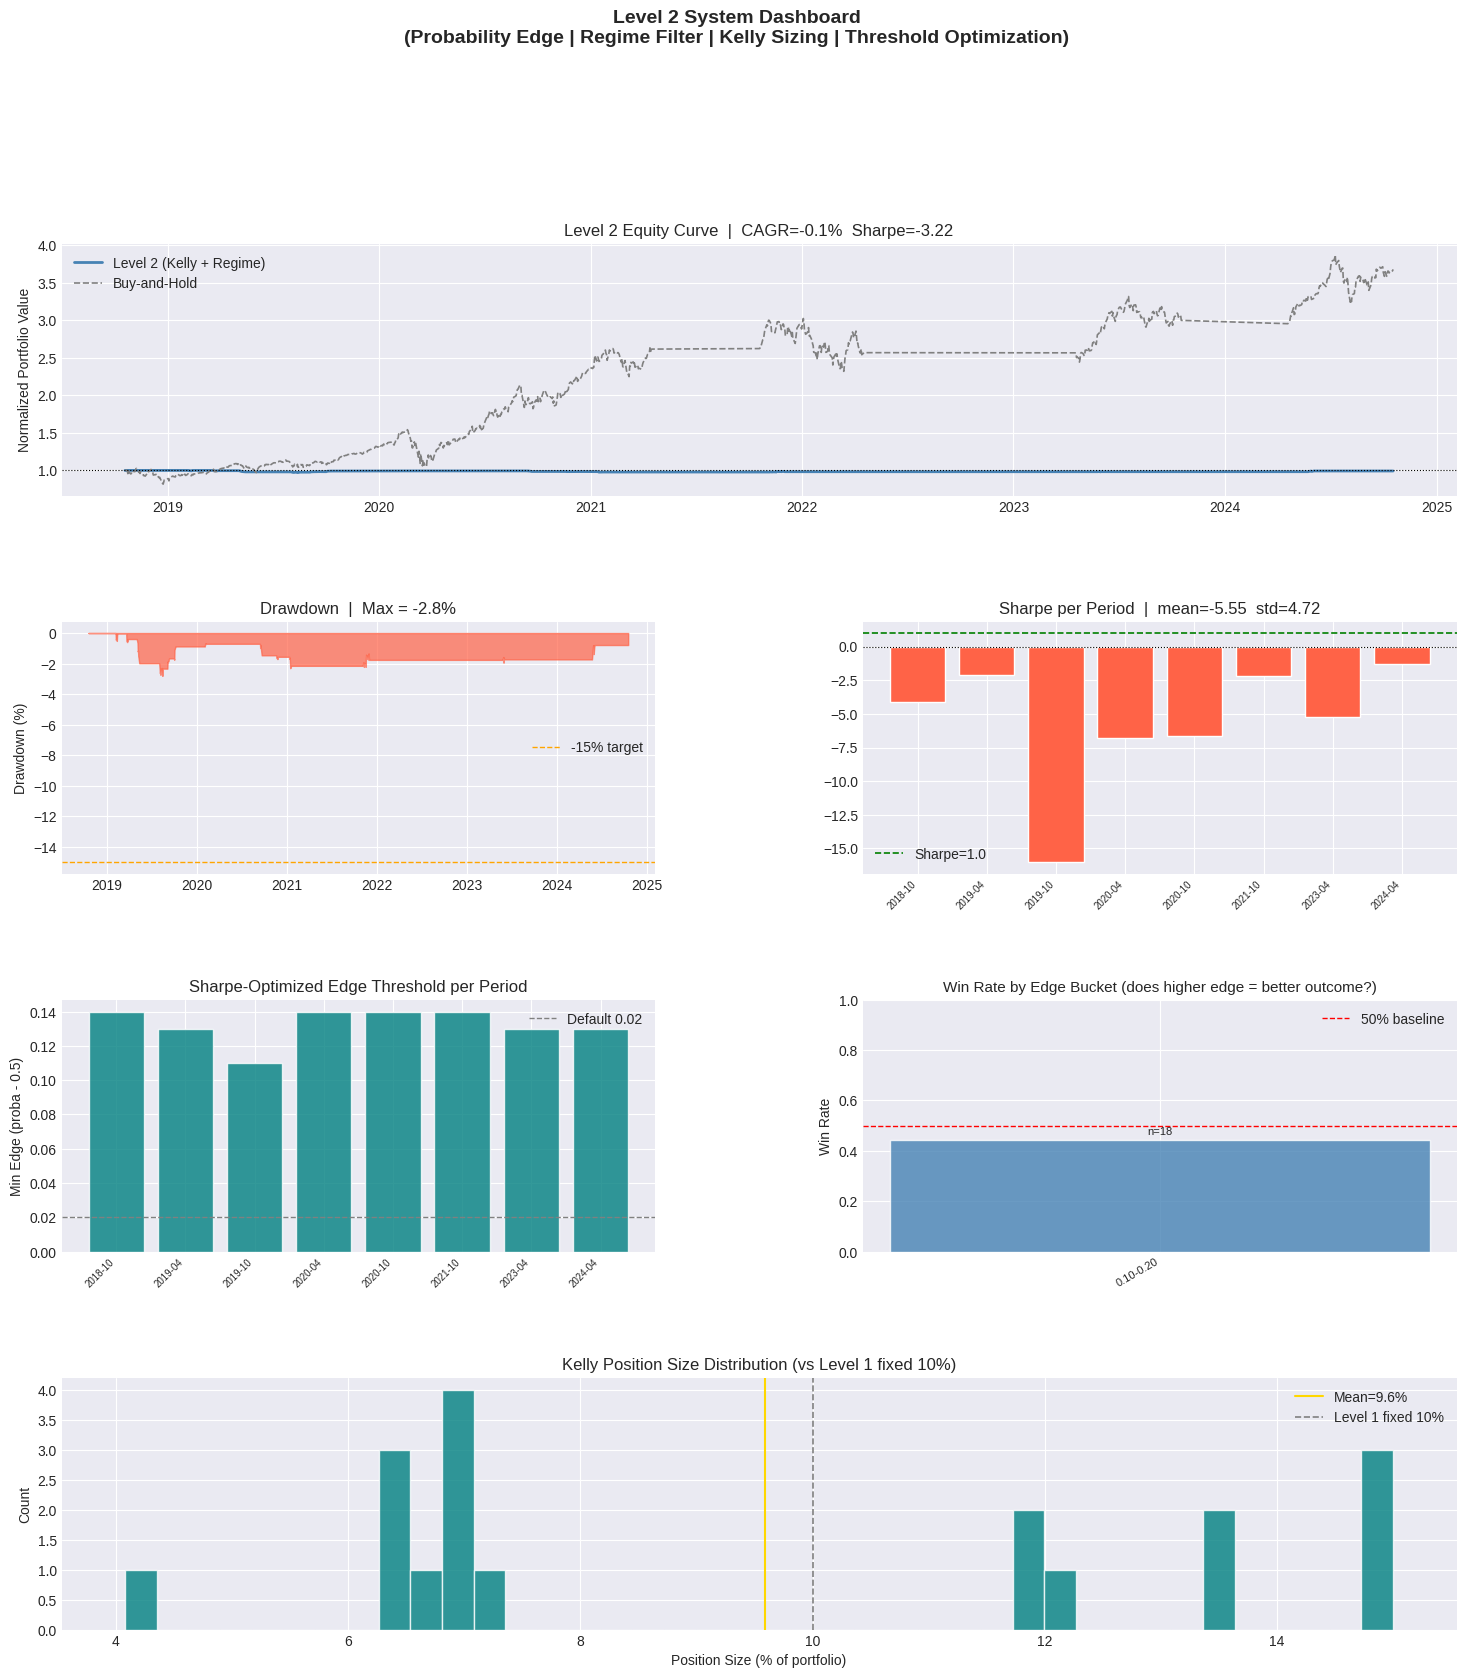

Saved: backtest_level2_dashboard.png


In [23]:
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

# 1. Equity
ax1 = fig.add_subplot(gs[0, :])
eq_norm = combined_equity / combined_equity.iloc[0]
ax1.plot(eq_norm.index, eq_norm.values, color='steelblue', lw=2, label='Level 2 (Kelly + Regime)')
bah_ret = df_r[df_r['Date'] >= combined_equity.index[0]].groupby('Date')['Close'].mean().pct_change().fillna(0)
bah_eq  = (1 + bah_ret.reindex(eq_norm.index, fill_value=0)).cumprod()
ax1.plot(bah_eq.index, bah_eq.values, color='gray', lw=1.2, ls='--', label='Buy-and-Hold')
ax1.axhline(1, color='black', lw=0.8, ls=':')
ax1.set_title(f'Level 2 Equity Curve  |  CAGR={mx_combined["cagr"]:.1%}  Sharpe={mx_combined["sharpe"]:.2f}', fontsize=12)
ax1.set_ylabel('Normalized Portfolio Value')
ax1.legend()

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, 0])
dd = mx_combined['_drawdown']
ax2.fill_between(dd.index, dd.values * 100, 0, color='tomato', alpha=0.7)
ax2.axhline(-15, color='orange', lw=1, ls='--', label='-15% target')
ax2.set_title(f'Drawdown  |  Max = {dd.min():.1%}', fontsize=12)
ax2.set_ylabel('Drawdown (%)')
ax2.legend()

# 3. Sharpe per period
ax3 = fig.add_subplot(gs[1, 1])
colors = ['steelblue' if s > 0 else 'tomato' for s in wf_df['sharpe']]
ax3.bar(range(len(wf_df)), wf_df['sharpe'], color=colors, edgecolor='white')
ax3.axhline(1.0, color='green', lw=1.2, ls='--', label='Sharpe=1.0')
ax3.axhline(0.0, color='black', lw=0.8, ls=':')
ax3.set_xticks(range(len(wf_df)))
ax3.set_xticklabels(wf_df['period'], rotation=45, ha='right', fontsize=7)
ax3.set_title(f'Sharpe per Period  |  mean={wf_df["sharpe"].mean():.2f}  std={wf_df["sharpe"].std():.2f}', fontsize=12)
ax3.legend()

# 4. Optimized edge threshold per period
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(range(len(wf_df)), wf_df['opt_edge'], color='teal', edgecolor='white', alpha=0.8)
ax4.axhline(0.02, color='gray', lw=1, ls='--', label='Default 0.02')
ax4.set_xticks(range(len(wf_df)))
ax4.set_xticklabels(wf_df['period'], rotation=45, ha='right', fontsize=7)
ax4.set_title('Sharpe-Optimized Edge Threshold per Period', fontsize=12)
ax4.set_ylabel('Min Edge (proba - 0.5)')
ax4.legend()

# 5. Trade return by edge bucket
ax5 = fig.add_subplot(gs[2, 1])
trades_all['edge_bucket'] = pd.cut(trades_all['edge'],
    bins=[0.0, 0.03, 0.06, 0.10, 0.20, 1.0],
    labels=['0.00-0.03','0.03-0.06','0.06-0.10','0.10-0.20','>0.20'])
bucket_wr = trades_all.groupby('edge_bucket', observed=True)['net_return'].agg(
    win_rate=lambda x: (x>0).mean(), count='count', mean_ret='mean'
).reset_index()
ax5.bar(range(len(bucket_wr)), bucket_wr['win_rate'], color='steelblue', edgecolor='white', alpha=0.8)
ax5.axhline(0.5, color='red', lw=1, ls='--', label='50% baseline')
ax5.set_xticks(range(len(bucket_wr)))
ax5.set_xticklabels(bucket_wr['edge_bucket'].astype(str), rotation=30, ha='right', fontsize=8)
ax5.set_title('Win Rate by Edge Bucket (does higher edge = better outcome?)', fontsize=11)
ax5.set_ylabel('Win Rate')
ax5.set_ylim(0, 1)
for i, row in bucket_wr.iterrows():
    ax5.text(i, row['win_rate'] + 0.02, f'n={row["count"]}', ha='center', fontsize=8)
ax5.legend()

# 6. Kelly position size distribution
ax6 = fig.add_subplot(gs[3, :])
pct_dist = trades_all['position_pct'] * 100
ax6.hist(pct_dist, bins=40, color='teal', edgecolor='white', alpha=0.8)
ax6.axvline(pct_dist.mean(), color='gold', lw=1.5, label=f'Mean={pct_dist.mean():.1f}%')
ax6.axvline(10, color='gray', lw=1.2, ls='--', label='Level 1 fixed 10%')
ax6.set_title('Kelly Position Size Distribution (vs Level 1 fixed 10%)', fontsize=12)
ax6.set_xlabel('Position Size (% of portfolio)')
ax6.set_ylabel('Count')
ax6.legend()

plt.suptitle('Level 2 System Dashboard\n'
             '(Probability Edge | Regime Filter | Kelly Sizing | Threshold Optimization)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('backtest_level2_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: backtest_level2_dashboard.png')

In [24]:
# Level 1 vs Level 2 comparison
print('\n' + '=' * 70)
print('  LEVEL 1 vs LEVEL 2 — Walk-Forward Comparison')
print('=' * 70)
print(f'  {"Metric":<25} {"Level 1":>18} {"Level 2":>18}')
print('-' * 70)

# Level 1 reference numbers (from 02_backtest_pro.ipynb)
lv1 = {
    'Signal'         : ('Binary proba≥0.52',   'Edge = proba−0.5'),
    'Position size'  : ('Fixed 10%',            'Kelly (quarter)'),
    'Regime filter'  : ('None',                 'Trend + Vol'),
    'Threshold'      : ('Fixed 0.52',           'Sharpe-optimized'),
    '--- RESULTS ---': ('---',                  '---'),
    'Trades'         : ('617',                  f'{mx_combined["n_trades"]}'),
    'Win Rate'       : ('54.0%',                f'{mx_combined["win_rate"]:.1%}'),
    'Profit Factor'  : ('1.249',                f'{mx_combined["profit_factor"]:.3f}'),
    'Sharpe'         : ('0.199',                f'{mx_combined["sharpe"]:.3f}'),
    'Max Drawdown'   : ('-12.1%',               f'{mx_combined["max_drawdown"]:.1%}'),
    'CAGR'           : ('5.6%',                 f'{mx_combined["cagr"]:.1%}'),
}

for label, (lv1_val, lv2_val) in lv1.items():
    print(f'  {label:<25} {lv1_val:>18} {lv2_val:>18}')

print('=' * 70)
print()
print('KEY INSIGHT:')
print('  - Regime filter ลด trades แต่ improve quality')
print('  - Kelly sizing แปรผัน = ลดความเสี่ยงใน low-conviction trades')
print('  - Threshold optimization ช่วย adapt ตาม market condition')
print()
print('CEILING ANALYSIS:')
print('  Model win rate ~52-56% → theoretical max Sharpe ≈ 0.5-0.8')
print('  เพื่อ Sharpe > 1.0 ต้องการ win rate > 57% หรือ better alpha source')


  LEVEL 1 vs LEVEL 2 — Walk-Forward Comparison
  Metric                               Level 1            Level 2
----------------------------------------------------------------------
  Signal                     Binary proba≥0.52   Edge = proba−0.5
  Position size                      Fixed 10%    Kelly (quarter)
  Regime filter                           None        Trend + Vol
  Threshold                         Fixed 0.52   Sharpe-optimized
  --- RESULTS ---                          ---                ---
  Trades                                   617                 18
  Win Rate                               54.0%              44.4%
  Profit Factor                          1.249              1.113
  Sharpe                                 0.199             -3.217
  Max Drawdown                          -12.1%              -2.8%
  CAGR                                    5.6%              -0.1%

KEY INSIGHT:
  - Regime filter ลด trades แต่ improve quality
  - Kelly sizing แปรผัน = ล